# Lab | QLoRA Tuning using PEFT from Hugging Face

<!-- ### Introduction to Quantization & Fine-tune a Quantized Model -->

**Note:** This is more or less the same notebook you saw in the previous lesson, but that is ok. This is an LLM fine-tuning lab. In class we used a set of datasets and models, and in the labs you are required to change the LLMs models and the datasets including the pre-processing pipelines.

# Brief Introduction to Quantization
The main idea of quantization is simple: Reduce the precision of floating-point numbers, which normally occupy 32 bits, to integers of 8 or even 4 bits.

This reduction occurs in the model’s parameters, specifically in the weights of the neural layers, and in the activation values that flow through the model’s layers.

This means that we not only achieve an improvement in the model’s storage size and memory consumption but also greater agility in its calculations.

Naturally, there is a loss of precision, but particularly in the case of 8-bit quantization, this loss is minimal.



## Let's see a example of a quantized number.

In reality, what I want to examine is the precision loss that occurs when transitioning from a 32-bit number to a quantized 8/4-bit number and then returning to its original 32-bit value.

First, I'm going to create a function to quantize and another to unquantize.

In [1]:
#Importing necesary linbraries
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
#Functions to quantize and unquantize
def quantize(value, bits=4):
    quantized_value = np.round(value * (2**(bits - 1) - 1))
    return int(quantized_value)

def unquantize(quantized_value, bits=4):
    value = quantized_value / (2**(bits - 1) - 1)
    return float(value)

Quatizied values:

In [3]:
quant_4 = quantize(0.622, 4)
print (quant_4)
quant_8 = quantize(0.622, 8)
print(quant_8)

4
79


Unquantized values:

In [4]:
unquant_4 = unquantize(quant_4, 4)
print(unquant_4)
unquant_8 = unquantize(quant_8, 8)
print(unquant_8)

0.5714285714285714
0.6220472440944882


If we consider that the original number was 0.622, it can be said that 8-bit quantization barely loses precision, and the loss from 4-bit quantization is manageable.

In [5]:
x = np.linspace(-1, 1, 50)
y = [math.cos(val) for val in x]


y_quant_8bit = np.array([quantize(val, bits=8) for val in y])
y_unquant_8bit = np.array([unquantize(val, bits=8) for val in y_quant_8bit])

y_quant_4bit = np.array([quantize(val, bits=4) for val in y])
y_unquant_4bit = np.array([unquantize(val, bits=4) for val in y_quant_4bit])


Let’s plot a curve with the unquantized values of a cosine.


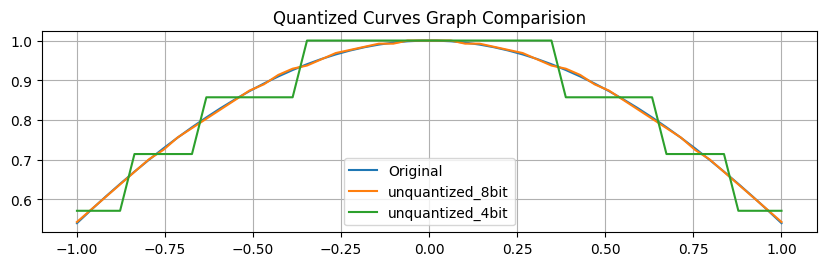

In [6]:
plt.figure(figsize=(10, 12))

plt.subplot(4, 1, 1)
plt.plot(x, y, label="Original")
plt.plot(x, y_unquant_8bit, label="unquantized_8bit")
plt.plot(x, y_unquant_4bit, label="unquantized_4bit")
plt.legend()
plt.title("Quantized Curves Graph Comparision")
plt.grid(True)

As you can see, the difference between the 8-bit and the original values is minimal. However, we need to use 4-bit quantization if we want to load the 7B Model into a 16GB GPU without problems.


# QLoRA. Fine-tuning a 4-bit Quantized Model using LoRA.
We are going to fine-tune with LoRA a 7B Model Quantizated to 4 bits.

## Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [7]:
# 1️⃣ Fix Triton and bitsandbytes issues
!pip uninstall -y triton bitsandbytes
!pip install -q triton==2.1.0
!pip install -q bitsandbytes==0.43.1
!pip install -q --upgrade bitsandbytes
!pip install -q triton==3.5.0

# 2️⃣ Install TRL (required for SFTTrainer)
!pip install -q trl

Found existing installation: triton 3.6.0
Uninstalling triton-3.6.0:
  Successfully uninstalled triton-3.6.0
ERROR: Could not find a version that satisfies the requirement triton==2.1.0 (from versions: 2.2.0, 2.3.0, 2.3.1, 3.0.0, 3.1.0, 3.2.0, 3.3.0, 3.3.1, 3.4.0, 3.5.0, 3.5.1, 3.6.0)
ERROR: No matching distribution found for triton==2.1.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires triton==3.6.0; platform_system == "Linux", but you have triton 3.5.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# !pip install -q accelerate==0.29.3
# !pip install -q bitsandbytes==0.43.1
# !pip install -q trl==0.8.6
# !pip install -q peft==0.10.0
# !pip install -q transformers==4.40.0

I'm going to download the peft and Transformers libraries from their repositories on GitHub instead of using pip. This is not strictly necessary, but this way, you can get the newest versions of the libraries with support for newer models. If you want to check one of the latest models, you can use this trick.


In [ ]:
#Install the lastest versions of peft & transformers library recommended
#if you want to work with the most recent models
#!pip install -q git+https://github.com/huggingface/peft.git
#!pip install -q git+https://github.com/huggingface/transformers.git

From the Transformers library, we import the necessary classes to load the model and the tokenizer.

The notebook is ready to work with different Models I tested it with models from the Bloom Family and Llama-3.

I recommend you to test different models.

In [8]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTTrainer
import torch

## Hugging Face login

## Load Model

In [9]:
#Use any model you want, if you want to do some fast test, just use the smallest one.

#model_name = "bigscience/bloomz-560m"
#model_name="bigscience/bloom-1b1"
#model_name = "bigscience/bloom-7b1"
#target_modules = ["query_key_value"]

model_name = "bigscience/bloom-7b1"
target_modules = ["query_key_value"] #YOU MAY CHANGE THIS BASED ON YOUR MODEL

To load the model, we need a configuration class that specifies how we want the quantization to be performed. We’ll achieve this with the BitesAndBytesConfig from the Transformers library.

In [10]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

We are specifying the use of 4-bit quantization and also enabling double quantization to reduce the precision loss.

For the bnb_4bit_quant_type parameter, I've used the recommended value in the paper [QLoRA: Efficient Finetuning of Quantized LLMs.](https://arxiv.org/abs/2305.14314)

Now, we can go ahead and load the model.

In [11]:
device_map = {"": 0}
foundation_model = AutoModelForCausalLM.from_pretrained(model_name,
                    quantization_config=bnb_config,
                    device_map=device_map,
                    use_cache = False)



config.json:   0%|          | 0.00/739 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/365 [00:00<?, ?it/s]

Now we have the quantized version of the model in memory. Yo can try to load the unquantized version to see if it's possible.

In [12]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [13]:
#this function returns the outputs from the model received, and inputs.
def get_outputs(model, inputs, max_new_tokens=100):#PLAY WITH ARGS AS YOU SEE FIT
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.5, #Avoid repetition.
        early_stopping=False, #The model can stop before reach the max_length
        eos_token_id=tokenizer.eos_token_id,
    )
    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [14]:
#Inference original model
input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(foundation_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

["I want you to act as a motivational coach for me.\n- I don't know what that means, sir...\nYou will be my personal cheerleader and mentor in the field of business management\nAnd if you're not upto it then I'll find someone who is!\nSir...sir..please listen..\n"]


The answer is good enough, the models used is a really well trained Model. But we will try to improve the quality with a sort fine-tuning process.


## Preparing the Dataset.
The Dataset useds is:

https://huggingface.co/datasets/fka/awesome-chatgpt-prompts

In [15]:
from datasets import load_dataset
dataset = "fka/awesome-chatgpt-prompts"

#Create the Dataset to create prompts.
data = load_dataset(dataset)

data = data.map(lambda samples: tokenizer(samples["prompt"]), batched=True)
train_sample = data["train"].select(range(50))

del data
train_sample = train_sample.remove_columns('act')

display(train_sample)

README.md: 0.00B [00:00, ?B/s]

prompts.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1305 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'for_devs', 'type', 'contributor', 'input_ids', 'attention_mask'],
    num_rows: 50
})

In [16]:
print(train_sample[:1])

{'prompt': ['Imagine you are an experienced Ethereum developer tasked with creating a smart contract for a blockchain messenger. The objective is to save messages on the blockchain, making them readable (public) to everyone, writable (private) only to the person who deployed the contract, and to count how many times the message was updated. Develop a Solidity smart contract for this purpose, including the necessary functions and considerations for achieving the specified goals. Please provide the code and any relevant explanations to ensure a clear understanding of the implementation.'], 'for_devs': [True], 'type': ['TEXT'], 'contributor': ['ameya-2003'], 'input_ids': [[186402, 1152, 1306, 660, 72560, 28857, 167625, 84544, 20165, 376, 1002, 26168, 267, 30479, 17477, 613, 267, 120755, 238776, 17, 1387, 47881, 632, 427, 14565, 29866, 664, 368, 120755, 15, 16997, 4054, 136044, 375, 4859, 12, 427, 39839, 15, 9697, 1242, 375, 13614, 12, 3804, 427, 368, 2298, 5268, 109891, 368, 17477, 15, 53

## Fine-Tuning.
The first step will be to create a LoRA configuration object where we will set the variables that specify the characteristics of the fine-tuning process.

In [19]:
# TARGET_MODULES
target_modules = ["query_key_value"]
# https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220

import peft
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16, #As bigger the R bigger the parameters to train.
    lora_alpha=16, # a scaling factor that adjusts the magnitude of the weight matrix. It seems that as higher more weight have the new training.
    target_modules=target_modules,
    lora_dropout=0.05, #Helps to avoid Overfitting.
    bias="none", # this specifies if the bias parameter should be trained.
    task_type="CAUSAL_LM"
)

The most important parameter is **r**, it defines how many parameters will be trained. As bigger the value more parameters are trained, but it means that the model will be able to learn more complicated relations between inputs and outputs.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_alpha**. Ad bigger the number more weight have the LoRA activations, it means that the fine-tuning process will have more impac as bigger is this value.

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

In [33]:
#Create a directory to contain the Model
import os
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")

In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

In [34]:
#Creating the TrainingArgs
import transformers
from transformers import TrainingArguments # , Trainer
training_args = TrainingArguments(
    output_dir=output_directory,
    auto_find_batch_size=True, # Find a correct bvatch size that fits the size of Data.
    learning_rate= 2e-4, # Higher learning rate than full fine-tuning.
    num_train_epochs=5,
    report_to='none'
)

Now we can train the model.
To train the model we need:


*   The Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.
* The LoRA config.





In [36]:
tokenizer.pad_token = tokenizer.eos_token
foundation_model = get_peft_model(foundation_model, lora_config)
trainer = SFTTrainer(
    model=foundation_model,
    args=training_args,
    train_dataset=train_sample,
    #dataset_text_field="prompt",
    #data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)
trainer.train()

Step,Training Loss


TrainOutput(global_step=35, training_loss=2.364733668736049, metrics={'train_runtime': 485.0276, 'train_samples_per_second': 0.515, 'train_steps_per_second': 0.072, 'total_flos': 1015262073520128.0, 'train_loss': 2.364733668736049})

In [39]:
#Save the model.
peft_model_path = os.path.join(output_directory, f"lora_model")


In [40]:
#Save the model.
trainer.model.save_pretrained(peft_model_path)

In [41]:
#In case you are having memory problems uncomment this lines to free some memory
import gc
import torch
del foundation_model
del trainer
del train_sample
torch.cuda.empty_cache()
gc.collect()

3342

## Inference with the pretrained model

In [42]:
#import peft
from peft import AutoPeftModelForCausalLM, PeftConfig
#import os

device_map = {"": 0}
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")
peft_model_path = os.path.join(output_directory, f"lora_model")


In [43]:
bnb_config2 = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    llm_int8_enable_fp32_cpu_offload=True
)

In [44]:
# Load the base model first with the quantization config, using device_map='auto' for better memory management
base_model_for_inference = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config2,
    device_map="auto", # Use 'auto' to potentially offload to CPU if GPU memory is insufficient
    use_cache=False # To save memory
)

# Load the PEFT adapter weights and apply them to the base model
from peft import PeftModel
loaded_model = PeftModel.from_pretrained(base_model_for_inference, peft_model_path)

# Ensure the model is in evaluation mode
loaded_model.eval()

Loading weights:   0%|          | 0/365 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.transformer.h.0.self_attention.query_key_value.lora_A.default.weight', 'base_model.model.transformer.h.0.self_attention.query_key_value.lora_B.default.weight', 'base_model.model.transformer.h.1.self_attention.query_key_value.lora_A.default.weight', 'base_model.model.transformer.h.1.self_attention.query_key_value.lora_B.default.weight', 'base_model.model.transformer.h.2.self_attention.query_key_value.lora_A.default.weight', 'base_model.model.transformer.h.2.self_attention.query_key_value.lora_B.default.weight', 'base_model.model.transformer.h.3.self_attention.query_key_value.lora_A.default.weight', 'base_model.model.transformer.h.3.self_attention.query_key_value.lora_B.default.weight', 'base_model.model.transformer.h.4.self_attention.query_key_value.lora_A.default.weight', 'base_model.model.transformer.h.4.self_attention.query_key_value

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): BloomForCausalLM(
      (transformer): BloomModel(
        (word_embeddings): Embedding(250880, 4096)
        (word_embeddings_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
        (h): ModuleList(
          (0-29): 30 x BloomBlock(
            (input_layernorm): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
            (self_attention): BloomAttention(
              (query_key_value): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=12288, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=12288, bias=False)
                )
           

In [45]:
import json
import os

adapter_config_path = os.path.join(peft_model_path, "adapter_config.json")

if os.path.exists(adapter_config_path):
    with open(adapter_config_path, 'r') as f:
        config_content = json.load(f)
    print("Content of adapter_config.json:")
    print(json.dumps(config_content, indent=2))
else:
    print(f"adapter_config.json not found at {adapter_config_path}")

Content of adapter_config.json:
{
  "alora_invocation_tokens": null,
  "alpha_pattern": {},
  "arrow_config": null,
  "auto_mapping": null,
  "base_model_name_or_path": null,
  "bias": "none",
  "corda_config": null,
  "ensure_weight_tying": false,
  "eva_config": null,
  "exclude_modules": null,
  "fan_in_fan_out": false,
  "inference_mode": true,
  "init_lora_weights": true,
  "layer_replication": null,
  "layers_pattern": null,
  "layers_to_transform": null,
  "loftq_config": {},
  "lora_alpha": 16,
  "lora_bias": false,
  "lora_dropout": 0.05,
  "megatron_config": null,
  "megatron_core": "megatron.core",
  "modules_to_save": null,
  "peft_type": "LORA",
  "peft_version": "0.18.1",
  "qalora_group_size": 16,
  "r": 16,
  "rank_pattern": {},
  "revision": null,
  "target_modules": [
    "query_key_value"
  ],
  "target_parameters": null,
  "task_type": "CAUSAL_LM",
  "trainable_token_indices": null,
  "use_dora": false,
  "use_qalora": false,
  "use_rslora": false
}


## Inference the fine-tuned model.

In [46]:
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(loaded_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

['I want you to act as a motivational coach.  I don\'t mean that in the sense of "just tell me what I\'m doing wrong", but rather help them see how their actions are affecting others.\nFor example if they have been rude and disrespectful towards another employee or customer then it is important']


The result is really good. Let's compare the answer of the pre-trained model with the fine-tuned one:

* **Pretrained Model**: 'I want you to act as a motivational coach. \xa0You are going on an adventure with me, and I need your help.\nWe will be traveling through the land of “What If.” \xa0 This is not some place that exists in reality; it’s more like one those places we see when watching'

* **Fine-Tuned Model**: 'I want you to act as a motivational coach.  I will provide some information about an individual or group of people who need motivation, and your role is help them find the inspiration they require in order achieve their goals successfully! You can use techniques such as positive reinforcement, visualization exercises etc., depending on what'

As you can see, the result is really similar to the samples contained in the dataset used to fine-tune the model. And we only trained the model for some epochs and with a really small number of rows.

 - Complete the prompts similar to what we did in class.
     - Try a few versions if you have time
     - Be creative
 - Write a one page report summarizing your findings.
     - Were there variations that didn't work well? i.e., where GPT either hallucinated or wrong
 - What did you learn?

Setup: bloom-7b1 quantized to 4-bit NF4, LoRA r=16, 50 training samples, 5 epochs, ~8 min on Colab Pro T4. Final training loss: 2.36.
Results:

Baseline: coherent but theatrical, dialogue-style output
Fine-tuned: structured, actionable coaching response — clear improvement in instruction-following from just 50 examples

Key learnings:

4-bit quantization makes 7B models fit in 16GB VRAM — without it you'd need ~28GB
LoRA trains only a tiny fraction of parameters while the frozen base model stays in memory
bitsandbytes has poor Windows support — use Colab for QLoRA
SFTTrainer simplifies the training loop significantly vs standard Trainer

Conclusion: QLoRA is a practical way to fine-tune large models on limited hardware with measurable results.